In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
!wget $data -O data-week-3.csv

--2026-09-30 06:17:44--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.009s  

2026-09-30 06:17:44 (101 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [4]:
df = pd.read_csv('data-week-3.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df['totalcharges'] = pd.to_numeric(df.totalcharges, errors='coerce')
df['totalcharges'] = df['totalcharges'].fillna(0)

df['churn'] = (df.churn == 'yes').astype(int)

In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [6]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [7]:
dv = DictVectorizer(sparse = False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [8]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [9]:
len(y_val)

1409

In [10]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
thresholds = np.linspace(0, 1, 21)
scores = []

for t in thresholds:
  churn_decision = (y_pred >= t)
  # score = (y_val == churn_decision).mean()
  score = accuracy_score(y_val,churn_decision)
  print('%.2f %.3f' % (t, score))
  scores.append(score)

0.00 0.274
0.05 0.513
0.10 0.608
0.15 0.662
0.20 0.703
0.25 0.735
0.30 0.759
0.35 0.764
0.40 0.781
0.45 0.791
0.50 0.803
0.55 0.802
0.60 0.796
0.65 0.789
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


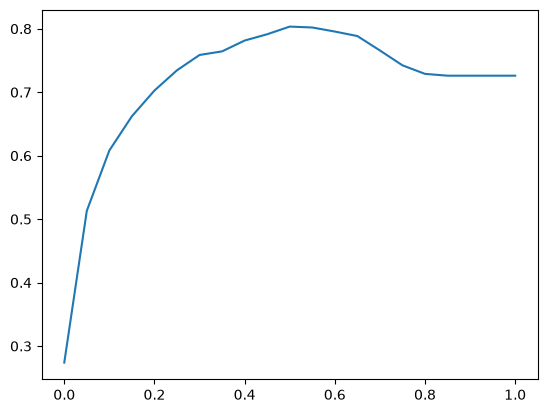

In [13]:
plt.plot(thresholds, scores)

In [14]:
from collections import Counter

In [15]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [16]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
actual_positive.sum(),actual_negative.sum()

(np.int64(386), np.int64(1023))

In [17]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)
predict_positive.sum(),predict_negative.sum()

(np.int64(315), np.int64(1094))

In [18]:
# true_positive
tp = (predict_positive & actual_positive).sum()
# true_negative
tn = (predict_negative & actual_negative).sum()
tp, tn

(np.int64(212), np.int64(920))

In [19]:
# false_positive
fp = (predict_positive & actual_negative).sum()
# false_negative
fn = (predict_negative & actual_positive).sum()
fp, fn

(np.int64(103), np.int64(174))

In [20]:
confusion_matrix = np.array([[tn,fp],
                             [fn, tp]
                            ])
confusion_matrix

array([[920, 103],
       [174, 212]])

In [21]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

In [22]:
(tp + tn) / (tp + tn + fp + fn)

np.float64(0.8034066713981547)

In [ ]:
# precision
p = tp / (tp+fp)
p

np.float64(0.6730158730158731)

In [24]:
# recall
r = tp / (tp+fn)
r

np.float64(0.5492227979274611)

In [25]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5492227979274611)

In [26]:
fpr = fp / (fp + tn)
fpr

np.float64(0.10068426197458455)

In [27]:
thresholds = np.linspace(0, 1, 101)
scores = []

for t in thresholds:
  actual_positive = (y_val == 1)
  actual_negative = (y_val == 0)

  predict_positive = (y_pred >= t)
  predict_negative = (y_pred < t)

  tp = (predict_positive & actual_positive).sum()
  tn = (predict_negative & actual_negative).sum()
  fp = (predict_positive & actual_negative).sum()
  fn = (predict_negative & actual_positive).sum()
  
  scores.append((t, tp, fp, fn, tn))

In [28]:
columns = ['threshold','tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns = columns)

In [29]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [30]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,532,20,491,0.948187,0.520039
20,0.2,339,372,47,651,0.878238,0.363636
30,0.3,293,247,93,776,0.759067,0.241447
40,0.4,253,175,133,848,0.655440,0.171065
50,0.5,212,103,174,920,0.549223,0.100684
60,0.6,151,53,235,970,0.391192,0.051808
70,0.7,69,13,317,1010,0.178756,0.012708
80,0.8,4,0,382,1023,0.010363,0.000000
90,0.9,0,0,386,1023,0.000000,0.000000


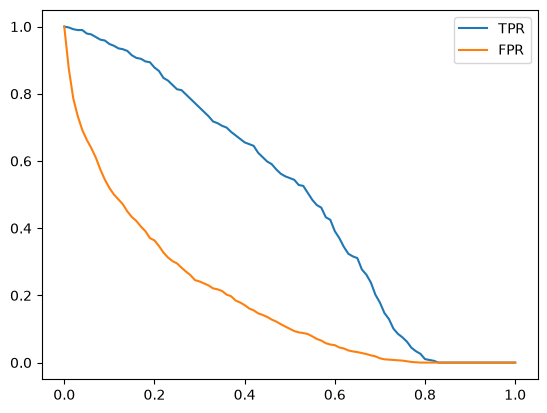

In [31]:
plt.plot(df_scores.threshold, df_scores.tpr, label = 'TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label = 'FPR')
plt.legend()


In [32]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [33]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [34]:
def tpr_fpr_dataframe(y_val, y_pred):
  thresholds = np.linspace(0, 1, 101)
  scores = []

  for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))
    
    columns = ['threshold','tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns = columns)
    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
  
  return df_scores

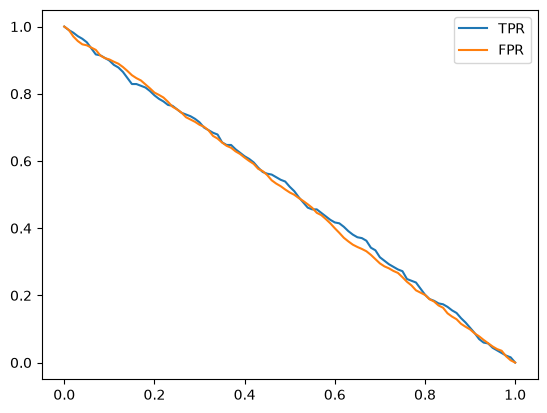

In [35]:
df_random = tpr_fpr_dataframe(y_val, y_rand)

plt.plot(df_random.threshold, df_random.tpr, label = 'TPR')
plt.plot(df_random.threshold, df_random.fpr, label = 'FPR')
plt.legend()


In [36]:
num_neg = (y_val == 0 ).sum()
num_pos = (y_val == 1 ).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [37]:
y_ideal = np.repeat([0,1],[num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [38]:
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [39]:
1-y_val.mean()

np.float64(0.7260468417317246)

In [40]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

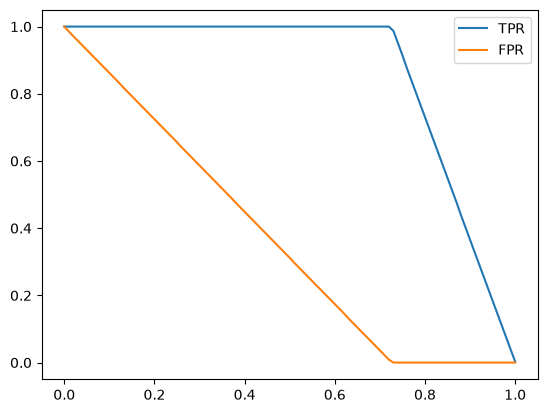

In [41]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)

plt.plot(df_ideal.threshold, df_ideal.tpr, label = 'TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label = 'FPR')
plt.legend()

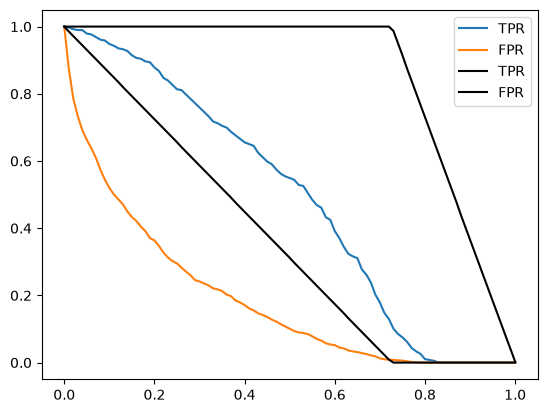

In [42]:
plt.plot(df_scores.threshold, df_scores.tpr, label = 'TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label = 'FPR')

# plt.plot(df_random.threshold, df_random.tpr, label = 'TPR')
# plt.plot(df_random.threshold, df_random.fpr, label = 'FPR')

plt.plot(df_ideal.threshold, df_ideal.tpr, label = 'TPR', color = 'black')
plt.plot(df_ideal.threshold, df_ideal.fpr, label = 'FPR', color = 'black')
plt.legend()



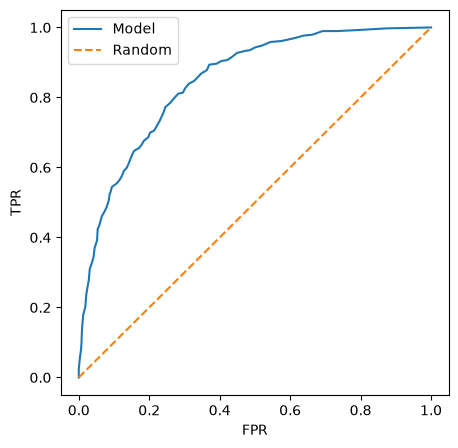

In [43]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')
# plt.plot(df_random.fpr,df_random.tpr, label='Random')
# plt.plot(df_ideal.fpr,df_ideal.tpr, label='Ideal')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()


In [44]:
from sklearn.metrics import roc_curve

In [45]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

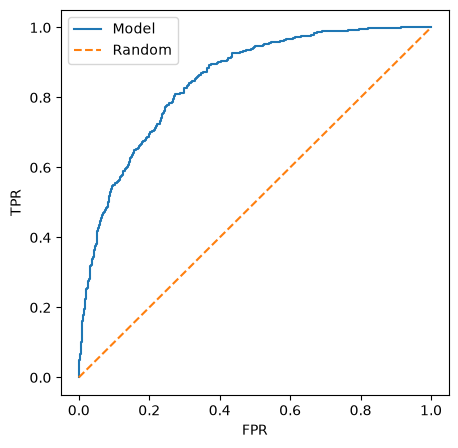

In [46]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()


In [49]:
from sklearn.metrics import auc

In [50]:
auc(fpr, tpr)

0.846286701208981

In [51]:
auc(df_scores.fpr, df_scores.tpr)

0.8460309260075264

In [52]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.846286701208981

In [53]:
from sklearn.metrics import roc_auc_score

In [54]:
roc_auc_score(y_val, y_pred)

0.846286701208981

In [55]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [56]:
import random

In [64]:
n = 100000
success = 0

for i in range(n):
  pos_ind = random.randint(0, len(pos) - 1)
  neg_ind = random.randint(0, len(neg) - 1)
  if pos[pos_ind] > neg[neg_ind]:
    success = success + 1

success / n

0.84612

In [67]:
n = 50000
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.84746)

In [86]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=5000)
    model.fit(X_train, y_train)
    
    return dv, model

In [69]:
dv, model = train(df_train, y_train, C=0.001)

In [70]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [71]:
y_pred = predict(df_val, dv, model)

In [72]:
from sklearn.model_selection import KFold

In [73]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [80]:
!pip install tqdm

In [81]:
from tqdm.auto import tqdm

In [87]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

C=0.001 0.825 +- 0.009
C=0.01 0.840 +- 0.008
C=0.1 0.842 +- 0.007
C=0.5 0.842 +- 0.007
C=1 0.842 +- 0.007
C=5 0.842 +- 0.007
C=10 0.842 +- 0.007


In [76]:
len(train_idx), len(val_idx)

(5070, 564)

In [88]:
scores

[0.8439175451955006,
 0.8447618692888359,
 0.8333172787477423,
 0.8348048698599475,
 0.8517500235323648]

In [95]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)
auc = roc_auc_score(y_test, y_pred)
auc

0.8583517501381259